<a href="https://colab.research.google.com/github/sambee5/data-science-coursework/blob/main/FastTrack/multlinexercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install bambi

In [2]:
from google.colab import files
from google.colab.output import eval_js
import io
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import graphviz as gv
import arviz as az
import pymc as pm
import bambi as bmb

## Exercises

You may use whatever resources you want to complete these exercises, so long as you cite your sources and the use of AI.

I recommend copying and pasting from the examples I did [here](https://github.com/thedarredondo/data-science-fundamentals/blob/main/FastTrack/IntroMultLinSF.ipynb); giving you something to copy and paste from was half my intent in writing that lesson.

**Task1**

Get the [penguins data from my github page](https://github.com/thedarredondo/data-science-fundamentals/blob/main/Data/penguins.csv) into this colab document.

I suggest downloading the csv, and then using the code from [notes document](https://github.com/thedarredondo/data-science-fundamentals/blob/main/FastTrack/IntroMultLinSF.ipynb) to upload it into this jupyter notebook.

In [3]:
penguins = pd.read_csv('https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/refs/heads/main/Data/penguins.csv',dtype={'species':'category'})
penguins.head()

,species,island,bill_length,bill_depth,flipper_length,body_mass,sex,year
0,Adelie,Torgersen,3.91,1.87,18.1,3.75,male,2007
1,Adelie,Torgersen,3.95,1.74,18.6,3.80,female,2007
2,Adelie,Torgersen,4.03,1.80,19.5,3.25,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,3.67,1.93,19.3,3.45,female,2007


**Task2**

Make a pair plot with the penguins data and describe the scatter plots. Make sure to describe any patterns.

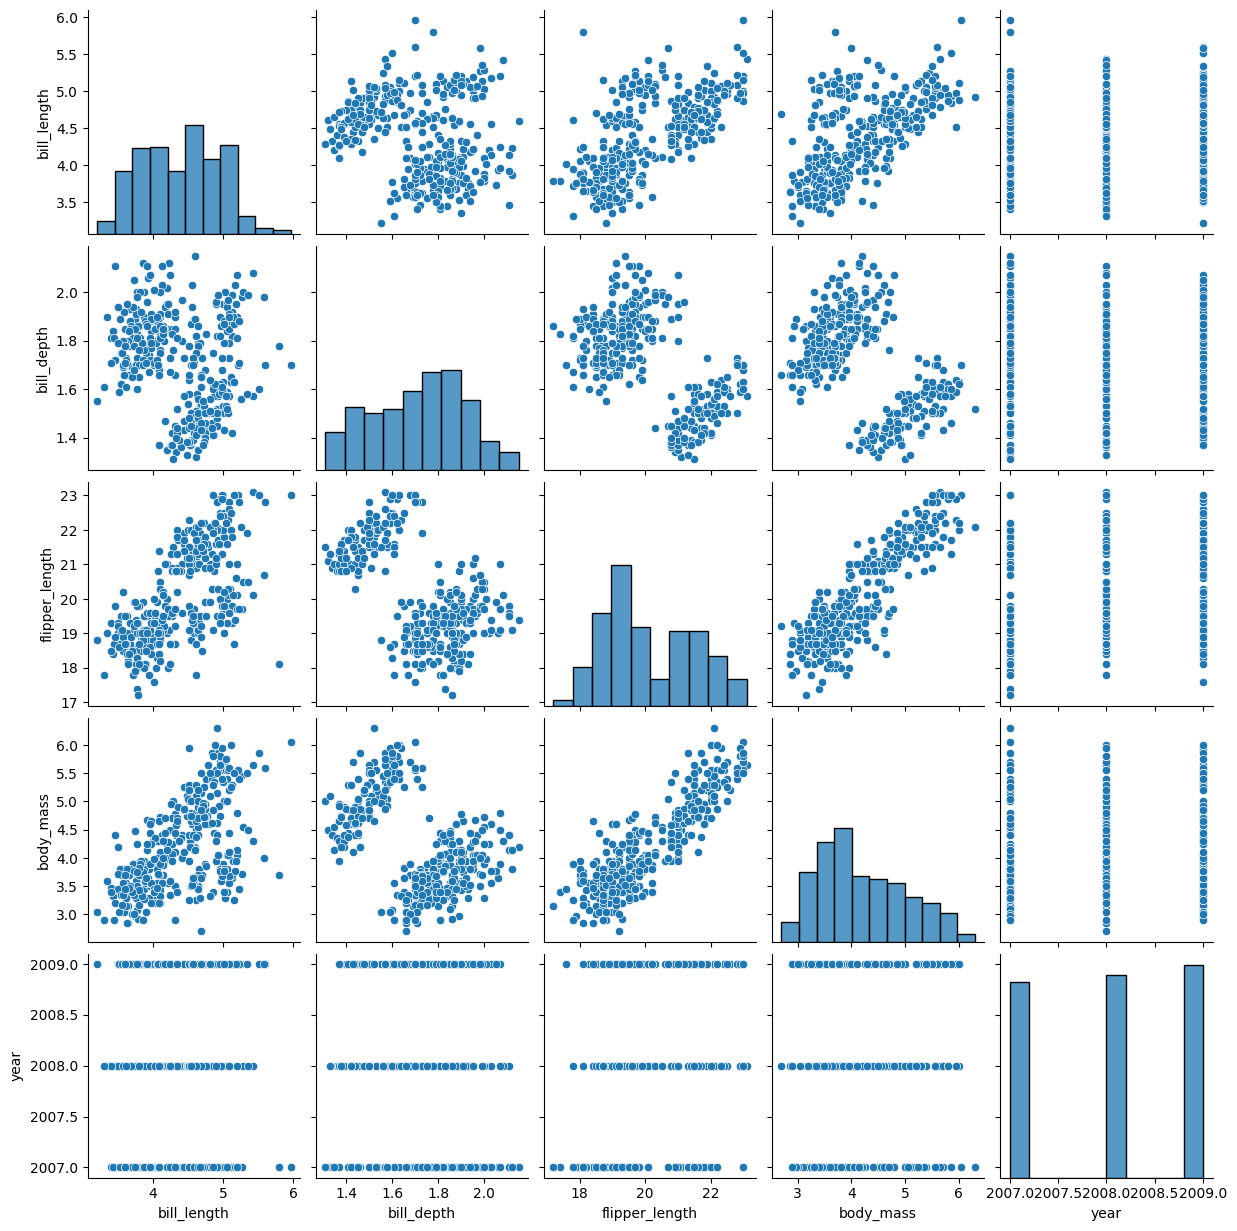

In [4]:
sns.pairplot(penguins)

There is a predominantly linear relationship between flipper_length and body_mass. A lot of the relationships intuitively make sense. However, many of the scatterplots are seperated into two clusters, each likely seperated based on species. Species is prbably plays a major role in how these relationships play out. Each of these clusters have their own linear relationship.

**Task3**

Make a causal diagram corresponding to the penguins data. Remember to include the species variable, even though it likely didn't show up in your pair plot.

In [5]:
penguins = penguins.dropna()


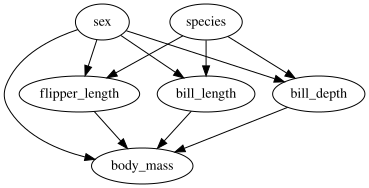

In [6]:
bodydag = gv.Digraph(name="penguinDAG")

bodydag.node('A','species')
bodydag.node('B','sex')
bodydag.node('C','flipper_length')
bodydag.node('D','bill_length')
bodydag.node('E','bill_depth')
bodydag.node('F','body_mass')


bodydag.edges(['AC','AD','AE','BC','BD','BE','BF','CF','DF','EF'])

bodydag

Sex and species have tremendous influence on these factors. This is because a male emperor penguin may have a longer flipped (because they are tall) which in turn influence body mass.

**Task4**

Create a Bayesian generalized linear model (GLM) to represent and test your causal diagram.

Then, conduct both types of posterior predictve check, and use them to comment on the model's fit. Note that you may want to make several plots here.

You may use another model type if want--[such as BART](https://github.com/thedarredondo/data-science-fundamentals/blob/main/Unit8/Unit8NotesSF.ipynb)--so long as it is Bayesian, and it represents your causal diagram.

I want to predict body_mass using these variables.

In [7]:
model_peng1 = bmb.Model("`body_mass` ~ `flipper_length` + (`flipper_length`|`species`) + (`flipper_length`|`sex`) + `bill_depth` + (`bill_depth`|`species`) + (`bill_depth`|`sex`) + (`bill_length`|`species`) + (`bill_length`|`sex`) + `sex` + `species`", data=penguins)

In [ ]:
idata_peng1 = model_peng1.fit(idata_kwargs={"log_likelihood":True})

In [9]:
model_peng1.predict(idata_peng1, kind="response")

<Axes: xlabel='body_mass'>

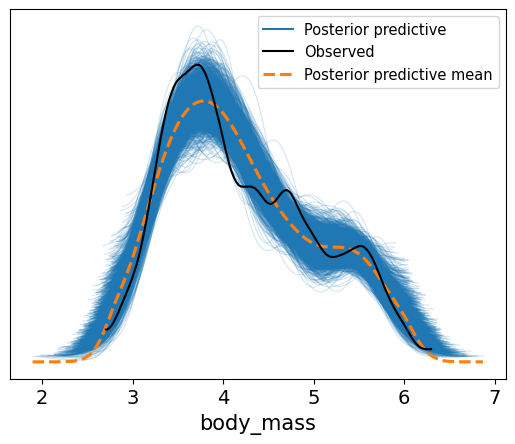

In [10]:
az.plot_ppc(idata_peng1)

It's pretty good...

**Task5**

Create as many other models as you need to test your causal hypotheses.

Then, "test" those causal hypotheses using the az.compare and az.plot_compare() functions.

In [11]:
model_peng2 = bmb.Model("`body_mass` ~ `flipper_length` + `flipper_length`:`species` + `flipper_length`:`sex` + `bill_depth` + `bill_depth`:`species` + `bill_depth`:`sex` + `bill_length`:`species` + `bill_length`:`sex` + `sex` + `species`", data=penguins)

In [ ]:
idata_peng2 = model_peng2.fit(idata_kwargs={"log_likelihood":True})

In [13]:
model_peng2.predict(idata_peng2, kind="response")

<Axes: xlabel='body_mass'>

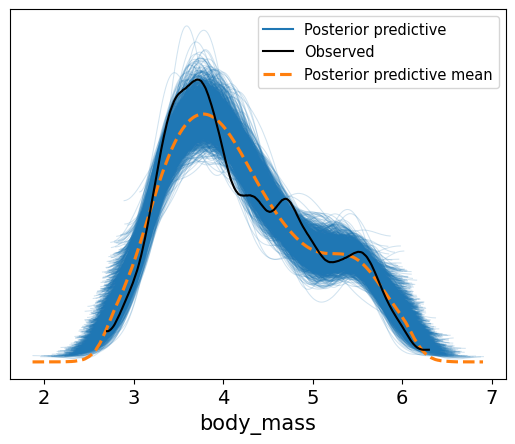

In [14]:
az.plot_ppc(idata_peng2)

This is a model that relies less on heirarchies which are less flexible than interactions, which I am using here. However, I'm curious if there predictors are more than I actually need--that is, are some of my variables overfitting my models?

In [16]:
model_peng3 = bmb.Model("`body_mass` ~ `flipper_length`  + `bill_depth` + `sex` + `species`", data=penguins)

In [ ]:
idata_peng3 = model_peng3.fit(idata_kwargs={"log_likelihood":True})

<Axes: xlabel='body_mass'>

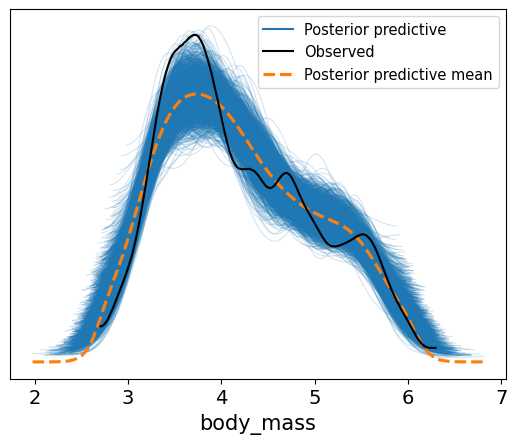

In [18]:
model_peng3.predict(idata_peng3, kind="response")
az.plot_ppc(idata_peng3)

Alright, so this one is worse than the other two models I've made so far which are modeled around my causal diagram. I guess I know enough about penguins to make a decent hypothesis about them (I've seen Happy Feet)

In [19]:
cmp_df = az.compare({"My Hyp.":idata_peng1,"Hypothesis w/ inter":idata_peng2,"Simple 3 vars":idata_peng3})


/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

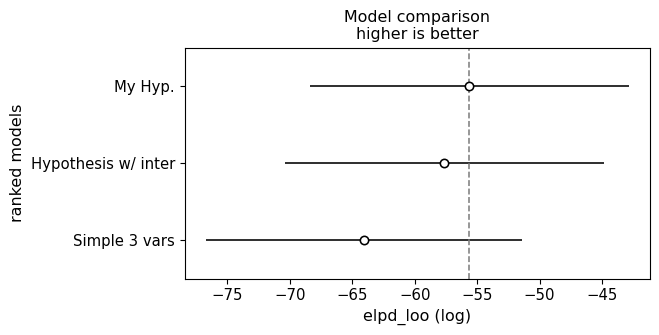

In [20]:
az.plot_compare(cmp_df)

My hypothesis worked the best and I think that heirarchies may have been a good choice. However, when running that model, I had a lot of divergences which is sort of an issue.

**Task6**

Answer the following:

- Which variables were most important?

- Was that surprising? Why?

- Did the model representing your causal diagram perform worse or better than other models?

- What did you learn about the data--and about penguins--from your models?

Sex, species, and the body characteristics were all very important variables for predicting the body mass of a penguin! This isn't too surprising because it makes sense to me that sex and species have a significant effect on a penguins weight, and some of the physical attributes about penguins also have trivial ties to body mass.

My causal diagram model ended up performing the best. I think my hypothesis was kind of solid and I wanted to distinguish between interactions and heirarchies in order to get more experience with them and making models with them. Species and sex matters when estimating a penguins weight.